# PyTorch MNIST – Complete Tutorial

## 1-Set Up Your Environment

Before we start coding, we need to set up our environment with the necessary packages:


In [60]:
!pip install torch torchvision matplotlib
!pip install torch torchvision


In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

For this tutorial, you’ll need PyTorch and torchvision installed. If you don’t have them yet, you can install them using pip:

## 2 – Load and Prepare the MNIST Dataset

MNIST contains 60,000 training images and 10,000 test images of handwritten digits (0-9). Here’s how to load and prepare the dataset:

In [62]:
# Define transformations for the images
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean and std
])

# Load the training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',  # Where to store the dataset
    train=True,     # This is training data
    download=True,  # Download if not present
    transform=transform  # Apply transformations
)

# Load the test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Let’s visualize some of the images to get a feel for the data:

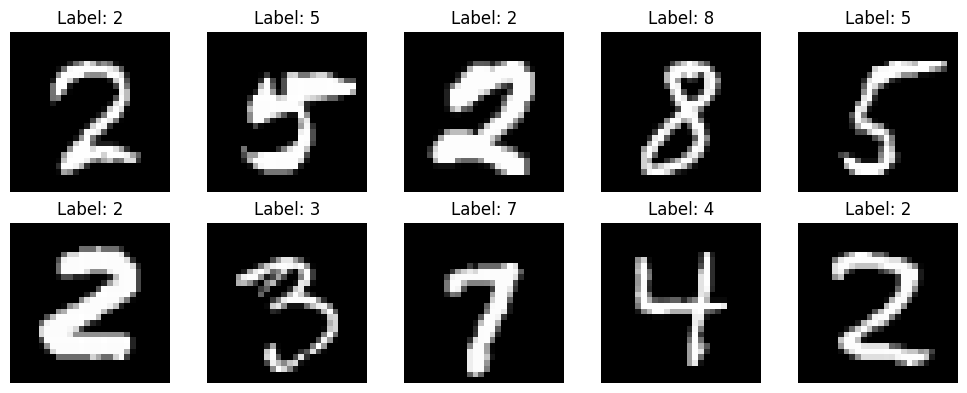

In [70]:
# Function to display images
def show_images(images, labels):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].reshape(28, 28), cmap='gray')
        axes[i].set_title(f"Label: {labels[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
show_images(images[:10], labels[:10])

Create a validation set:

In [ ]:
# Define the size of the sets
train_size = int(0.8 * len(train_dataset)) # 80% for training
val_size = len(train_dataset) - train_size # 20% for validation

# Split the dataset
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create new loaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")

Training set size: 48000
Validation set size: 12000


## 3 – Create a Neural Network Model CNN

Simple neural network (MLP) works reasonably well, convolutional neural networks (CNNs) are typically better for image processing tasks:

In [74]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        # Añadimos Dropout aquí
        self.dropout = nn.Dropout(0.25) 
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.dropout(x) # Aplicamos dropout
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the CNN model
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4 – Train the Neural Network

Here’s how to train the neural network:

In [75]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Training and Validation loop
num_epochs = 5
train_losses = [] 
val_losses = []
best_val_loss = float('inf') 

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() 
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Calculate average training loss for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss) # Ensure list is updated

    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0.0
    
    with torch.no_grad(): 
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss) # Ensure list is updated
    
    print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print("-> New best model saved!")

print('Training finished!')

Using device: cpu
Epoch [1/5] | Train Loss: 0.2436 | Val Loss: 0.0662
-> New best model saved!
Epoch [2/5] | Train Loss: 0.0665 | Val Loss: 0.0625
-> New best model saved!
Epoch [3/5] | Train Loss: 0.0474 | Val Loss: 0.0444
-> New best model saved!
Epoch [4/5] | Train Loss: 0.0370 | Val Loss: 0.0443
-> New best model saved!
Epoch [5/5] | Train Loss: 0.0304 | Val Loss: 0.0441
-> New best model saved!
Training finished!


I find it helpful to visualize the training process by plotting the loss:

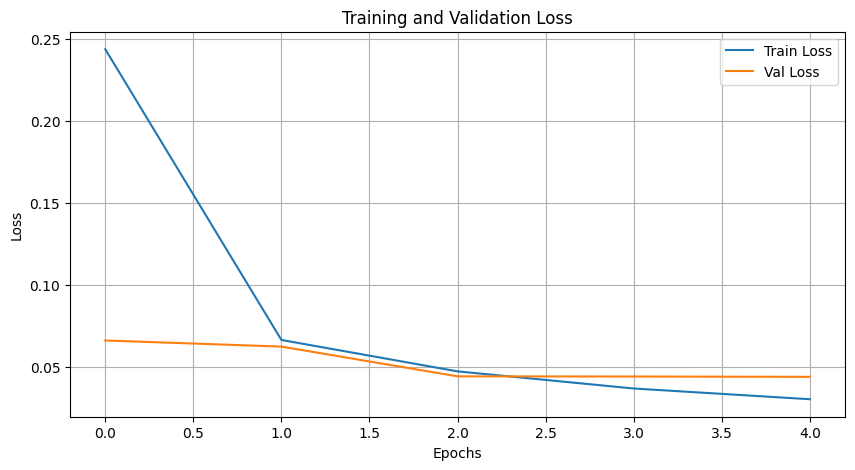

In [76]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss') # Opcional: ver ambas comparadas
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5 – Evaluate the Model

After training, we need to evaluate how well our model performs on unseen data:

In [77]:
# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on the test set: {accuracy:.2f}%')

Accuracy on the test set: 98.69%


Let’s visualize some predictions to see how our model is doing:

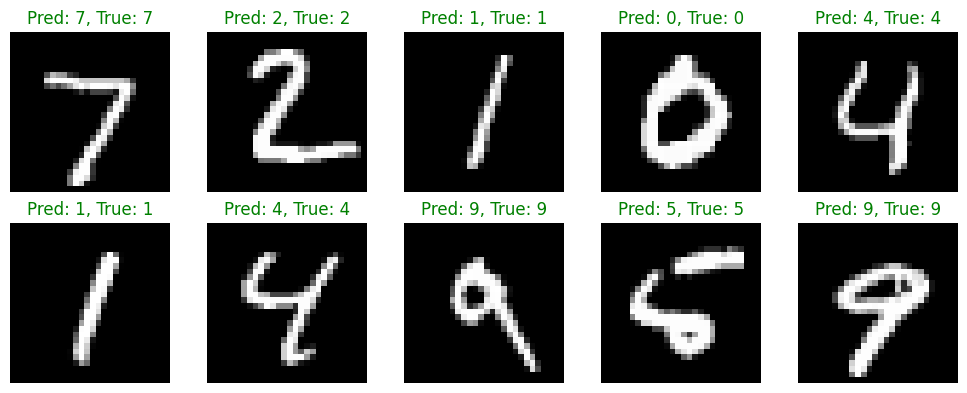

In [80]:
# Function to show predictions
def show_predictions(images, labels, preds):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].cpu().reshape(28, 28), cmap='gray')
        color = 'green' if preds[i] == labels[i] else 'red'
        axes[i].set_title(f"Pred: {preds[i]}, True: {labels[i]}", color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Get predictions for some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

# Show predictions
show_predictions(images[:10], labels[:10], preds[:10])

## 6 – Save and Load Your Model

It’s good practice to save your trained model so you can use it later without retraining:

In [34]:
# Save the model
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

# Load the model (for future use)
loaded_model = CNN()
loaded_model.load_state_dict(torch.load('mnist_model.pth'))
loaded_model.to(device)
loaded_model.eval()
print("Model loaded!")

Model saved!
Model loaded!
